In [2]:
print('hello world')

hello world


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Salary Prediction using Linear Regression")
print("="*50)

# Load the dataset
data = pd.read_csv('dataset/salary_data.csv')
print("Dataset loaded successfully!")
print(f"We have data for {len(data)} employees")
print("First 5 rows of the dataset:")
print(data.head())

Salary Prediction using Linear Regression
Dataset loaded successfully!
We have data for 375 employees
First 5 rows of the dataset:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  



Sample employee records:
   Years of Experience    Salary
0                  5.0   90000.0
1                  3.0   65000.0
2                 15.0  150000.0
3                  7.0   60000.0
4                 20.0  200000.0
5                  2.0   55000.0
6                 12.0  120000.0
7                  4.0   80000.0
8                  1.0   45000.0
9                 10.0  110000.0

The average salary in our dataset is: Rs.100577.3


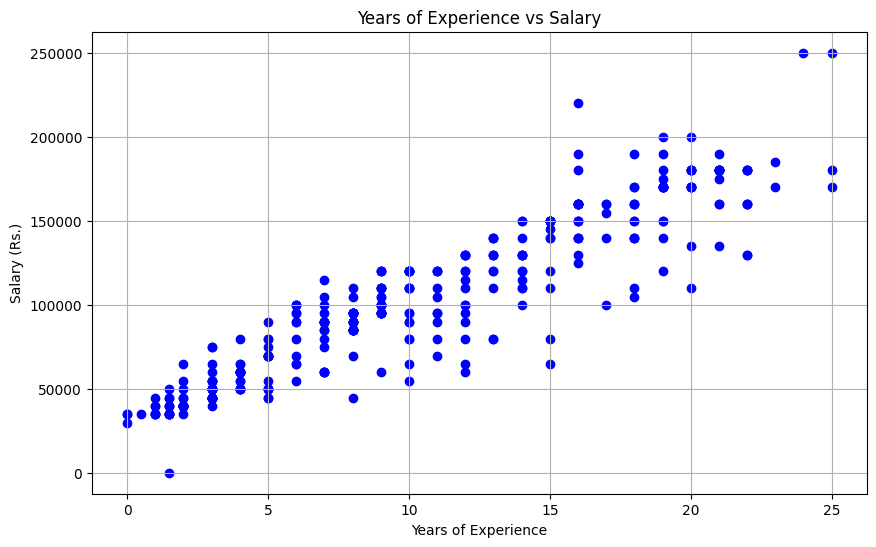

In [4]:
# Look at a few employee records
print("\nSample employee records:")
print(data[['Years of Experience', 'Salary']].head(10))

# Calculate the average salary
average_salary = data['Salary'].mean().round(1)
print(f"\nThe average salary in our dataset is: Rs.{average_salary}")

# Make a simple plot
plt.figure(figsize=(10, 6))
plt.scatter(data['Years of Experience'], data['Salary'], color='blue')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (Rs.)')
plt.grid()

In [ ]:
data[data.isnull().any(axis=1)]
data = data.dropna()
print(data.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [22]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
education_encoder = LabelEncoder()
job_encoder = LabelEncoder()

data['Gender'] = gender_encoder.fit_transform(data['Gender'])
data['Education Leve'] = education_encoder.fit_transform(data['Education Leve'])
data['Job Title'] = job_encoder.fit_transform(data['Job Title'])

print(data.columns.tolist())


['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary', 'Education Leve']


In [25]:
# Select features and target variable
feature = data[['Years of Experience', 'Age', 'Gender', 'Education Leve', 'Job Title']]
target = data['Salary']

x = feature # Feature (input)
y = target # Target variable (output)

print("Features (what we know)")
print(x.head())
print("Target variable (what we want to predict)")
print(y.head())

Features (what we know)
   Years of Experience   Age  Gender  Education Leve  Job Title
0                  5.0  32.0       1               0        159
1                  3.0  28.0       0               1         17
2                 15.0  45.0       1               2        130
3                  7.0  36.0       0               0        101
4                 20.0  52.0       1               1         22
Target variable (what we want to predict)
0     90000.0
1     65000.0
2    150000.0
3     60000.0
4    200000.0
Name: Salary, dtype: float64


In [26]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Data Split:")
print(f"Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

print(f"\nTraining features (x_train):\n{x_train.head()}")
print(f"\nTesting features (x_test):\n{x_test.head()}")
print(f"\nTraining target (y_train):\n{y_train.head()}")
print(f"\nTesting target (y_test):\n{y_test.head()}")

Data Split:
Training set size: 298
Testing set size: 75

Training features (x_train):
     Years of Experience   Age  Gender  Education Leve  Job Title
193                  7.0  34.0       1               0        141
75                  10.0  37.0       1               0         96
84                   2.0  29.0       0               0         56
363                  5.0  33.0       1               0         65
16                   7.0  33.0       0               1         83

Testing features (x_test):
     Years of Experience   Age  Gender  Education Leve  Job Title
329                 21.0  48.0       1               1         29
33                  10.0  39.0       0               0         84
15                  16.0  44.0       1               0         89
316                  6.0  34.0       0               1        117
57                  17.0  43.0       1               2        116

Training target (y_train):
193    95000.0
75     95000.0
84     40000.0
363    70000.0
16    

In [27]:
from sklearn.linear_model import LinearRegression

# Create and train the model
model = LinearRegression()
model.fit(x_train, y_train)

# Get the numbers the model learned
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Predicted Salary = {coefficient:.2f} x (Years of Experience) + {intercept:.2f}")
print("This means:")
print(f"Base Salary: {intercept:.1f} points")
print(f"Each Experience: {coefficient:.2f} points")
print(f"If a employee working 5 years: {5 * coefficient + intercept:.1f} points")
print(f"If a employee working 10 years: {10 * coefficient + intercept:.1f} points")

Predicted Salary = 2182.53 x (Years of Experience) + -64275.44
This means:
Base Salary: -64275.4 points
Each Experience: 2182.53 points
If a employee working 5 years: -53362.8 points
If a employee working 10 years: -42450.1 points
